In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 66.2 MB/s eta 0:00:00


In [2]:
import pennylane as qml
import matplotlib.pyplot as plt
import numpy as np

In [3]:
#1 StronglyEntanglingLayers
#The argument weights contains the weights for each layer. The number of layers L is therefore derived from the first dimension of weights.
#

 #       weights (tensor_like) – weight tensor of shape (L, M, 3)
 #       wires (Iterable) – wires that the template acts on

#      ranges (Sequence[int]) – sequence determining the range hyperparameter for each subsequent layer; if None using r=lmodM for the l th layer and M wires.
#       imprimitive (type of pennylane.ops.Operation) – two-qubit gate to use, defaults to CNOT




dev = qml.device('default.qubit', wires=4)

@qml.qnode(dev)
def circuit(parameters):
    qml.StronglyEntanglingLayers(weights=parameters, wires=range(4))
    return qml.expval(qml.Z(0))

shape = qml.StronglyEntanglingLayers.shape(n_layers=2, n_wires=4)
rng = np.random.default_rng(12345)
weights = rng.random(size=shape)

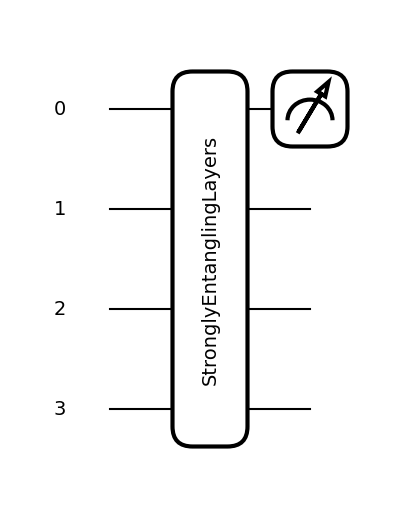

In [4]:
fig, ax = qml.draw_mpl(circuit)(weights)

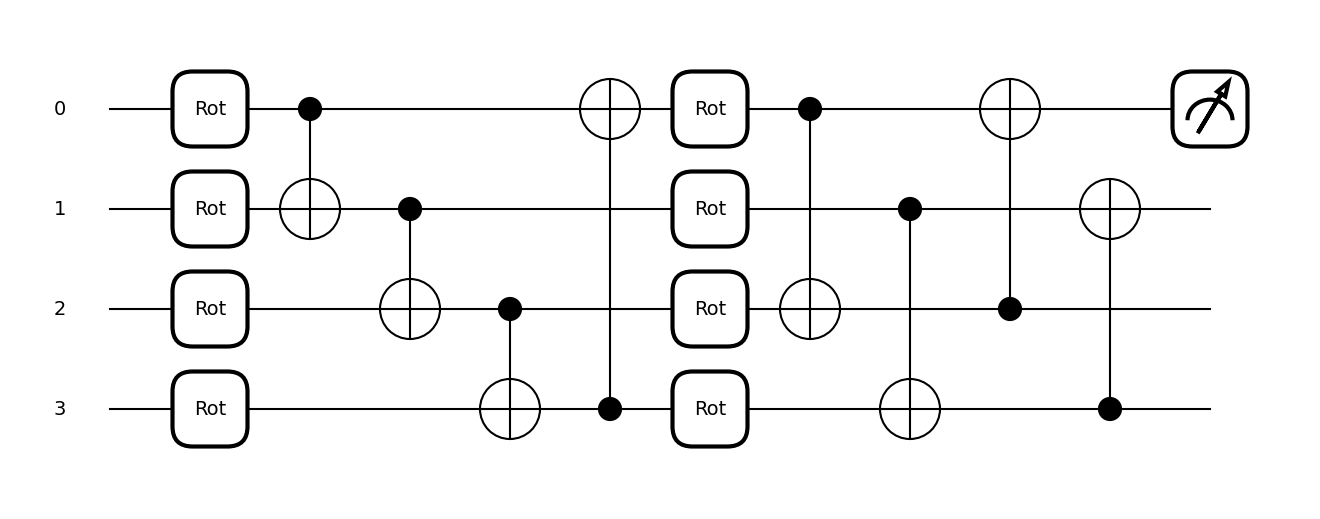

In [5]:
fig, ax = qml.draw_mpl(circuit, level="device")(weights)

In [6]:
dev = qml.device('default.qubit', wires=4)

@qml.qnode(dev)
def circuit(parameters):
    qml.StronglyEntanglingLayers(weights=parameters, wires=range(4), ranges=[2, 3], imprimitive=qml.ops.CZ)
    return qml.expval(qml.Z(0))

shape = qml.StronglyEntanglingLayers.shape(n_layers=2, n_wires=4)
rng = np.random.default_rng(12345)
weights = rng.random(size=shape)

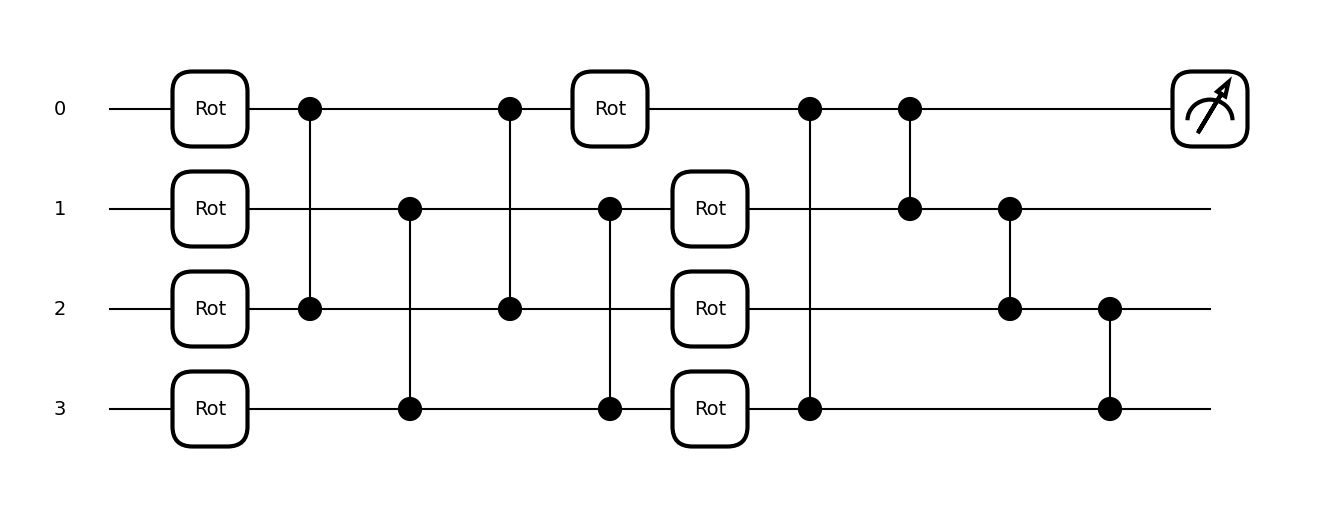

In [7]:
fig, ax = qml.draw_mpl(circuit, level="device")(weights)

In [8]:
# 2 Simplified Two Design

#        initial_layer_weights (tensor_like) – weight tensor for the initial rotation block, shape (M,)

#       weights (tensor_like) – tensor of rotation angles for the layers, shape (L, M-1, 2)

#       wires (Iterable) – wires that the template acts on



import pennylane as qml
from math import pi

n_wires = 3
dev = qml.device('default.qubit', wires=n_wires)

@qml.qnode(dev)
def circuit(init_weights, weights):
    qml.SimplifiedTwoDesign(initial_layer_weights=init_weights, weights=weights, wires=range(n_wires))
    return [qml.expval(qml.Z(i)) for i in range(n_wires)]

init_weights = [pi, pi, pi]
weights_layer1 = [[0., pi],
                  [0., pi]]
weights_layer2 = [[pi, 0.],
                  [pi, 0.]]
weights = [weights_layer1, weights_layer2]

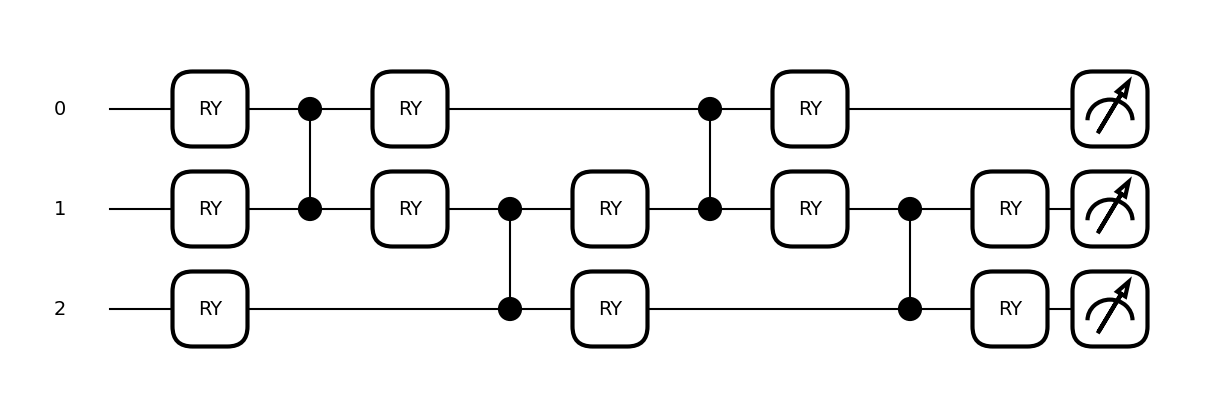

In [9]:
fig, ax = qml.draw_mpl(circuit, level="device")(init_weights,weights)

In [10]:
# 3 Basic Entangling Layers
#

#       weights (tensor_like) – Weight tensor of shape (L, len(wires)). Each weight is used as a parameter for the rotation.

#       wires (Iterable) – wires that the template acts on

#       rotation (pennylane.ops.Operation) – one-parameter single-qubit gate to use, if None, RX is used as default



import pennylane as qml
from math import pi

n_wires = 3
dev = qml.device('default.qubit', wires=n_wires)

@qml.qnode(dev)
def circuit(weights):
    qml.BasicEntanglerLayers(weights=weights, wires=range(n_wires))
    return [qml.expval(qml.Z(i)) for i in range(n_wires)]

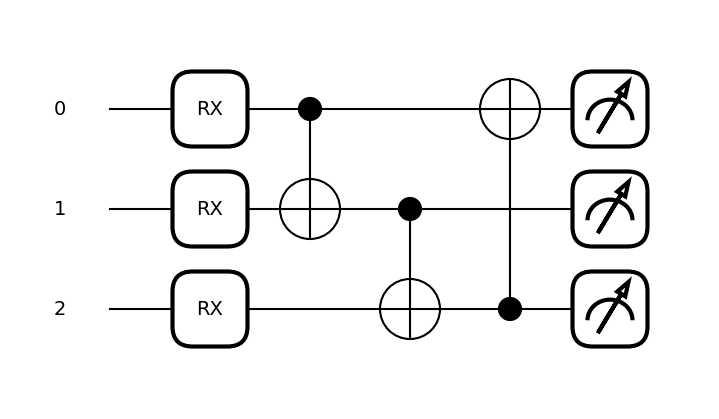

In [11]:
fig, ax = qml.draw_mpl(circuit, level="device")([[pi, pi, pi]])

In [12]:
#Define Tensor Network Ansatz

In [13]:
#1 Define One Block of MPS
import numpy as onp
import pennylane as qml
from pennylane import numpy as np


def block(weights, wires):
    qml.RX(weights[0], wires=wires[0])
    qml.RY(weights[1], wires=wires[1])
    qml.CNOT(wires=wires)

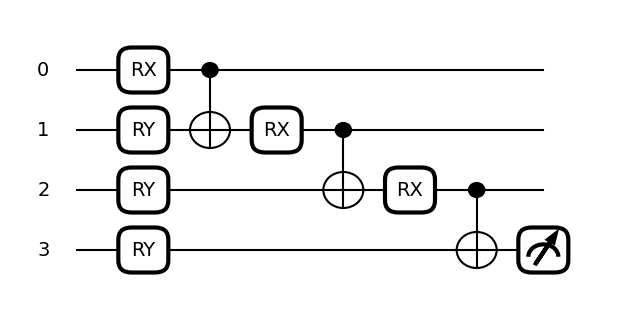

In [14]:
#The Full Circuit
#wires (Iterable) – wires that the template acts on

#n_block_wires (int) – number of wires per block

#block (Callable) – quantum circuit that defines a block

#n_params_block (int) – the number of parameters in a block; equal to the length of the weights argument in block

#template_weights (Sequence) – list containing the weights for all blocks

dev = qml.device("default.qubit", wires=4)


@qml.qnode(dev)
def circuit(template_weights):
    qml.MPS(
        wires=range(4),
        n_block_wires=2,
        block=block,
        n_params_block=2,
        template_weights=template_weights,
    )
    return qml.expval(qml.PauliZ(wires=3))


np.random.seed(1)
weights = np.random.random(size=[3, 2])
qml.drawer.use_style("black_white")
fig, ax = qml.draw_mpl(circuit, level="device")(weights)
fig.set_size_inches((6, 3))


In [15]:
#2 Define StronglyEntanglingLayers Block

def deep_block(weights, wires):
    qml.StronglyEntanglingLayers(weights, wires)

In [16]:
dev = qml.device("default.qubit", wires=4)


@qml.qnode(dev)
def circuit(template_weights):
    qml.MPS(
        wires=range(4),
        n_block_wires=2,
        block=deep_block,
        n_params_block=3,
        template_weights=template_weights,
    )
    return qml.expval(qml.PauliZ(wires=3))


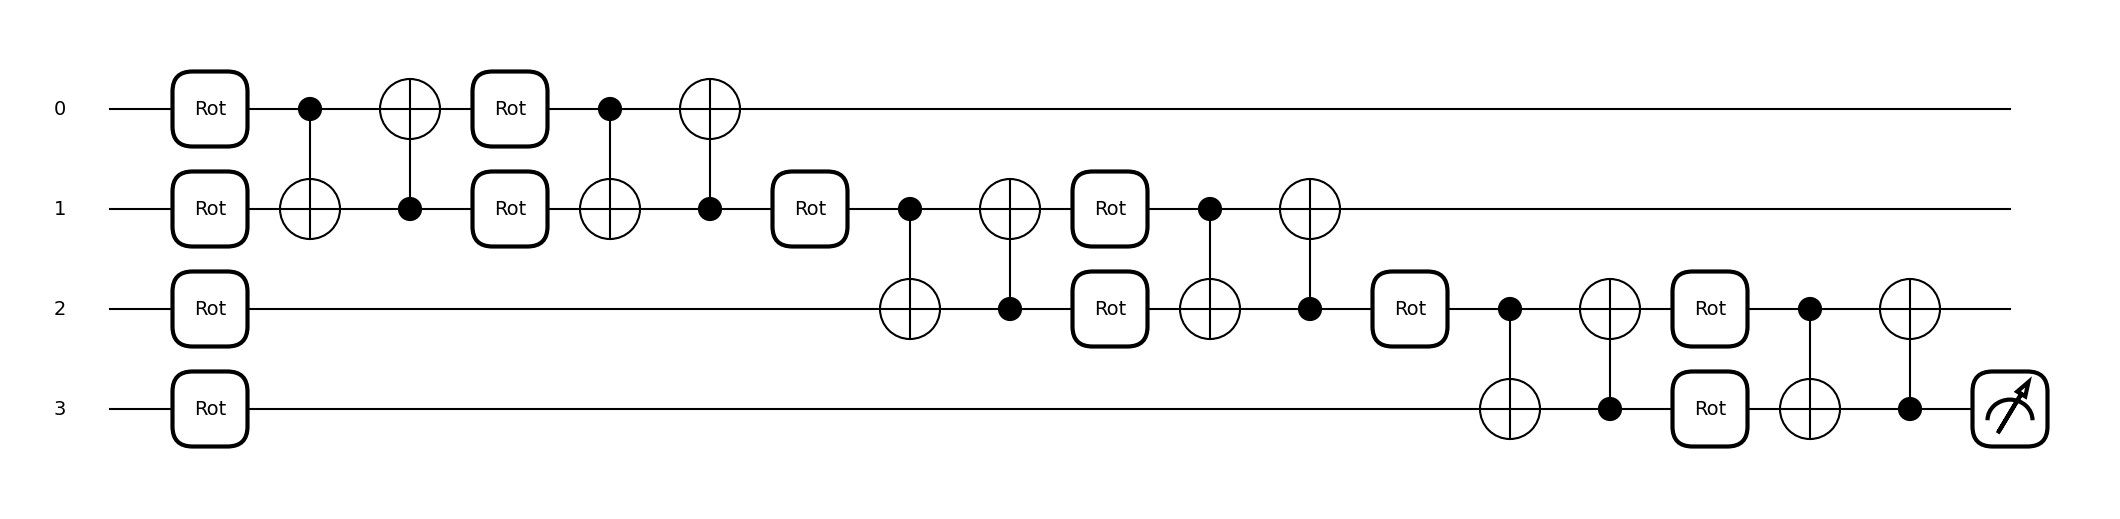

In [17]:
shape = qml.StronglyEntanglingLayers.shape(n_layers=2, n_wires=2)
template_weights = [np.random.random(size=shape)] * 3
fig, ax = qml.draw_mpl(circuit, level="device")(template_weights)


In [18]:
#3 SimplifiedTwoDesign Block
def wide_block(weights, wires):
    qml.SimplifiedTwoDesign(initial_layer_weights=weights[0], weights=weights[1], wires=wires)


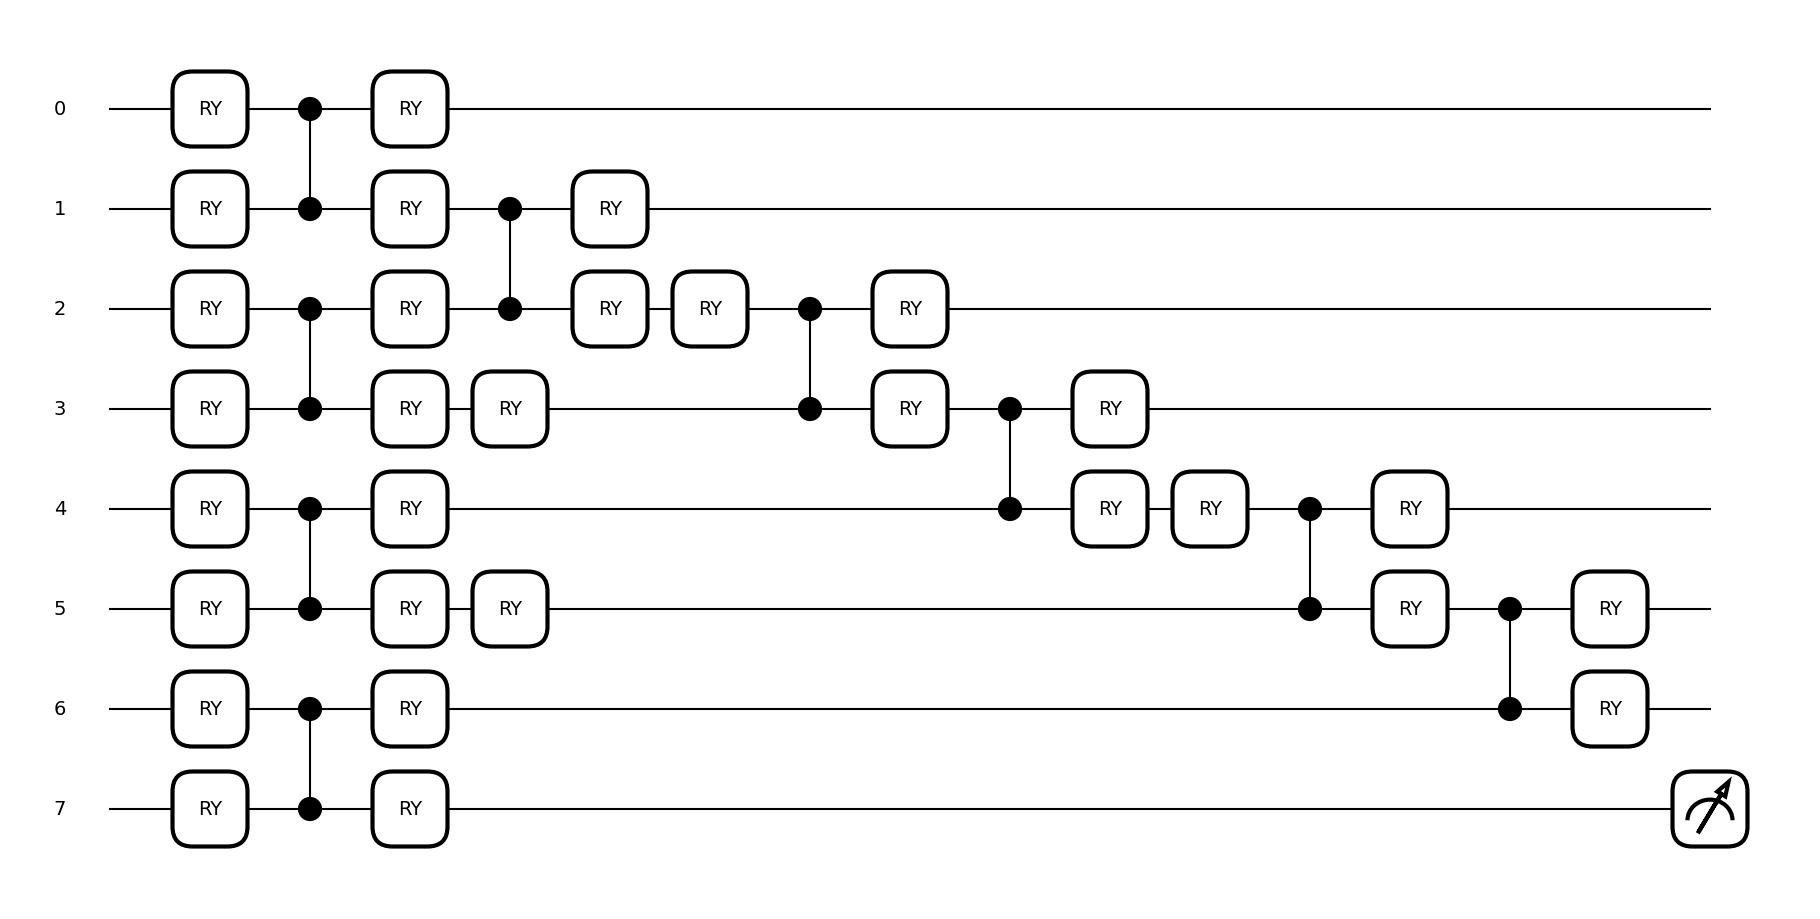

In [19]:
dev = qml.device("default.qubit", wires=8)


@qml.qnode(dev)
def circuit(template_weights):
    qml.MPS(
        wires=range(8),
        n_block_wires=4,
        block=wide_block,
        n_params_block=2,
        template_weights=template_weights,
    )
    return qml.expval(qml.PauliZ(wires=7))


shapes = qml.SimplifiedTwoDesign.shape(n_layers=1, n_wires=4)
weights = [onp.random.random(size=shape) for shape in shapes]
template_weights = onp.array([weights] * 3, dtype="object")
fig, ax = qml.draw_mpl(circuit, level="device")(template_weights)


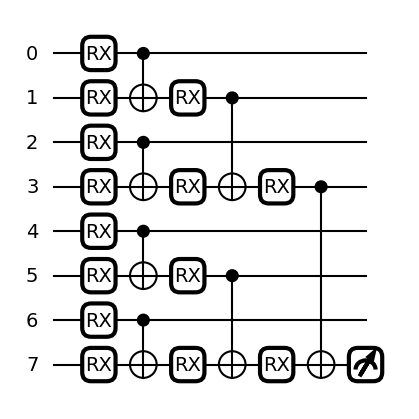

In [20]:
#4 TTN Anstaz
#

#      wires (Iterable) – wires that the template acts on

#       n_block_wires (int) – number of wires per block

#       block (Callable) – quantum circuit that defines a block

#       n_params_block (int) – the number of parameters in a block

#       template_weights (Sequence) – list containing the weights for all blocks


def block(weights, wires):
    qml.RX(weights[0], wires=wires[0])
    qml.RX(weights[1], wires=wires[1])
    qml.CNOT(wires=wires)


dev = qml.device("default.qubit", wires=8)


@qml.qnode(dev)
def circuit(template_weights):
    qml.TTN(
        wires=range(8),
        n_block_wires=2,
        block=block,
        n_params_block=2,
        template_weights=template_weights,
    )
    return qml.expval(qml.PauliZ(wires=7))


weights = np.random.random(size=[7, 2])
fig, ax = qml.draw_mpl(circuit, level="device")(weights)
fig.set_size_inches((4, 4))
